# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df=pd.read_csv('/data.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

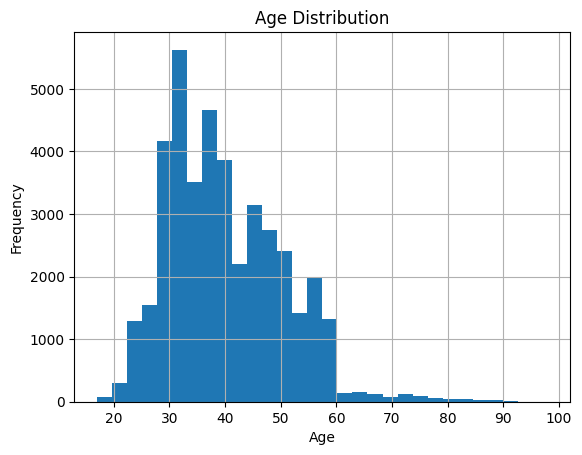

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data if df is not defined (for standalone execution)
if 'df' not in locals() and 'df' not in globals():
    df=pd.read_csv('/data.csv')

# Age distribution
plt.figure()
df['age'].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

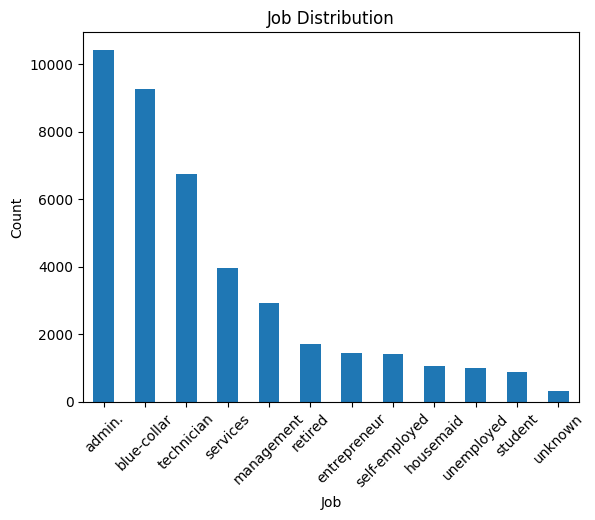

In [7]:
# Job distribution
plt.figure()
df['job'].value_counts().plot(kind='bar')
plt.title("Job Distribution")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Balance & Deposit Trends

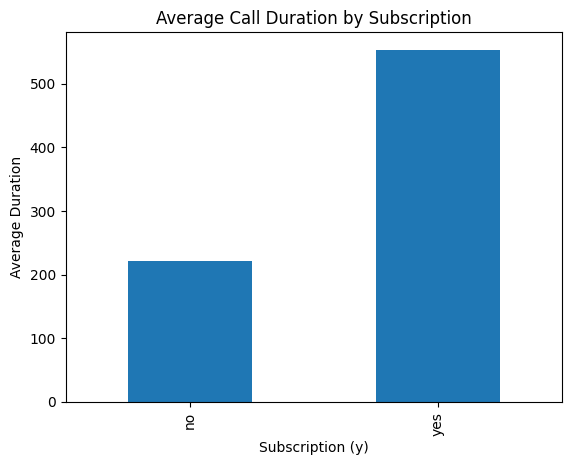

In [15]:
# Average balance by deposit subscription
avg_duration = df.groupby('y')['duration'].mean()

plt.figure()
avg_duration.plot(kind='bar')
plt.title("Average Call Duration by Subscription")
plt.xlabel("Subscription (y)")
plt.ylabel("Average Duration")
plt.show()

In [11]:
print("Available columns in df:")
print(df.columns)

Available columns in df:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


## Campaign Effectiveness

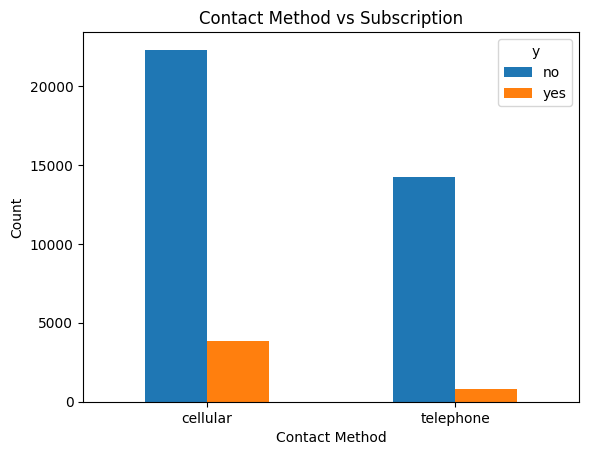

In [16]:
# Contact method analysis
contact_counts = df.groupby(['contact', 'y']).size().unstack()

contact_counts.plot(kind='bar')
plt.title("Contact Method vs Subscription")
plt.xlabel("Contact Method")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


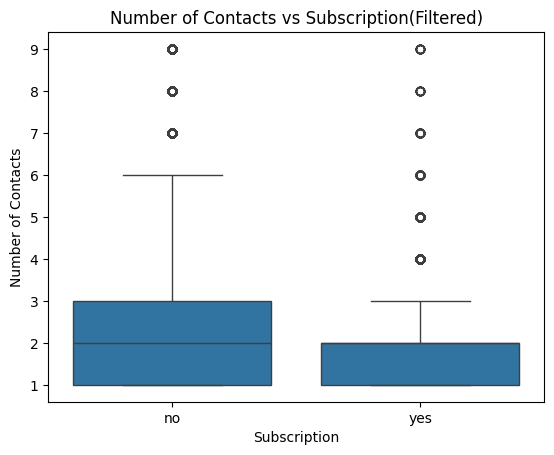

In [19]:
# Number of contacts vs deposit subscription

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
df_filtered = df[df['campaign'] < 10]
sns.boxplot(x='y', y='campaign', data=df_filtered)
plt.title("Number of Contacts vs Subscription(Filtered)")
plt.xlabel("Subscription")
plt.ylabel("Number of Contacts")
plt.show()

## Correlation Heatmap

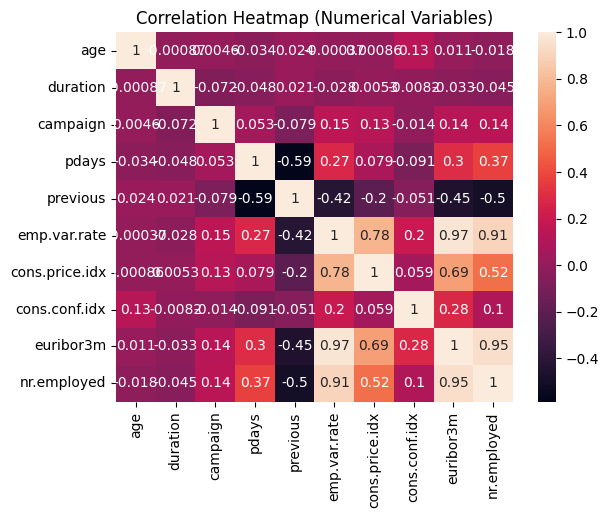

In [20]:
# Correlation of numerical variables
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = num_df.corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap (Numerical Variables)")
plt.show()


## Predictive Modeling (Logistic Regression)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Always reload df to ensure a clean state for preprocessing in this cell
df=pd.read_csv('/content/data.csv')

# Encode categorical variables
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Convert target variable (yes/no → 1/0)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#Prediction
y_pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9104151493080845


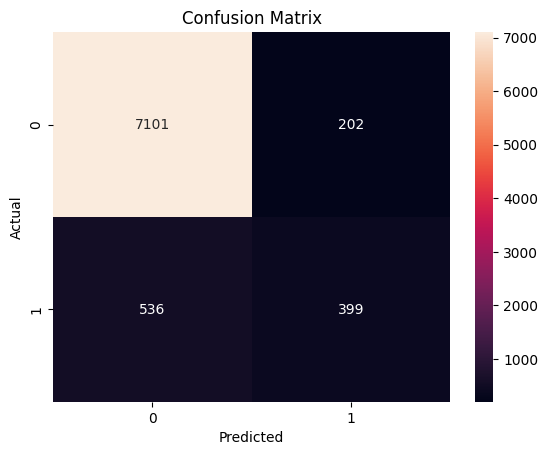

In [11]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

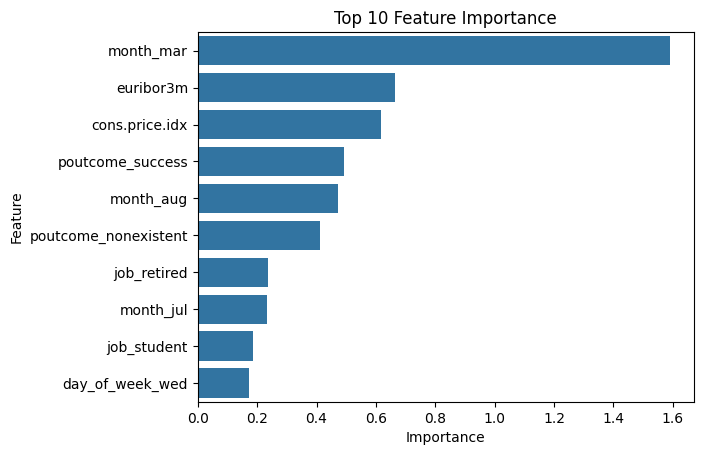

In [12]:
# Feature importance
import numpy as np

# Get coefficients
importance = model.coef_[0]

# Match with feature names
feature_names = X.columns

# Create DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort by importance
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top 10 Feature Importance")
plt.show()


## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.